**Task 1: Linear Regression**
---

**Mission**

A significant number of people in Rwanda drop out of school and take up small informal jobs like goods transportation, planting or chores at home. They normally come together in one place called ‘ku ndege in kinyarwanda slang’ and wait for those in need of this service to take them in. There is no proper linkage between these workers and job providers; and the job providers don't know what these workers will be able to expect to make.

The task here is to develop a regression model to predict the **monthly income (RWF)** of a young worker based on their profile (age, education, sector, location, skills...). Eventually, this can be used to help a Ku ndege worker understand his actual earning potential and to negotiate.

**Dataset description and source**

Youth Employment Status (Rwanda) dataset by **Kaggle**. It contains 10,000 records, 25 columns and data for youth between 16-25 years, including age, gender, education level, sector of interest, current employment sector, formal/informal, region, urban/rural, digital skills, technical skills, training, household info, and target ```monthly_income```. It is a Rwanda specific and youth specific use case.

*Source link: https://www.kaggle.com/datasets/talentsphere/youth-employment-status-rw*

In [18]:
# libraries used across the whole task
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.max_columns", None)
np.random.seed(42)

**1. Load and explore the data**
---

In [19]:
df = pd.read_csv("youth_unemployment_dataset.csv")
df.head()

,record_id,age,gender,education_level,education_mismatch,sector_of_interest,current_employment_sector,formal_informal,region,location_type,monthly_income,region_employment_rate,regional_unemployment_rate,unemployment_duration,digital_skills_level,technical_skills,training_participation,program_type,household_income,household_size,employment_outcome,intervention_effectiveness,employment_duration_post_intervention,youth_unemployment_rate,urban_rural_employment_rate
0,1,21,Female,TVET,False,Agriculture,Agriculture,Informal,Kigali,Urban,116417.11,62.63,25.35,NaN,Advanced,[o],True,Business Development,Medium,2,True,Moderately Effective,9.0,19.4,76.42
1,2,17,Female,TVET,False,Retail,Retail,Informal,Kigali,Rural,102002.15,84.97,18.48,NaN,Intermediate,[],True,Digital Skills,Medium,2,True,Effective,11.0,19.4,31.11
2,3,17,Male,TVET,False,Construction,Construction,Informal,Kigali,Urban,194184.21,61.70,29.55,NaN,Basic,[],False,NaN,Medium,7,True,Ineffective,10.0,19.4,70.70
3,4,25,Female,Primary or Less,False,Education,Education,Formal,Kigali,Urban,151178.79,79.71,16.60,NaN,Advanced,"['Marketing', 'Project Management']",False,NaN,Medium,2,True,Moderately Effective,11.0,19.4,70.04
4,5,21,Male,Secondary,False,Retail,Retail,Informal,Kigali,Urban,243337.48,71.86,27.23,NaN,Advanced,"['Marketing', 'Project Management']",False,NaN,Medium,7,True,Ineffective,2.0,19.4,57.05


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   record_id                              10000 non-null  int64  
 1   age                                    10000 non-null  int64  
 2   gender                                 10000 non-null  object 
 3   education_level                        10000 non-null  object 
 4   education_mismatch                     10000 non-null  bool   
 5   sector_of_interest                     10000 non-null  object 
 6   current_employment_sector              4973 non-null   object 
 7   formal_informal                        4973 non-null   object 
 8   region                                 10000 non-null  object 
 9   location_type                          10000 non-null  object 
 10  monthly_income                         4973 non-null   float64
 11  reg

In [4]:
df.describe()

,record_id,age,monthly_income,region_employment_rate,regional_unemployment_rate,unemployment_duration,household_size,employment_duration_post_intervention,youth_unemployment_rate,urban_rural_employment_rate
count,10000.00000,10000.000000,4973.000000,10000.000000,10000.000000,2514.000000,10000.000000,4973.000000,1.000000e+04,10000.000000
mean,5000.50000,20.507700,174478.541693,65.098606,19.963443,12.530628,4.485900,6.496280,1.940000e+01,59.849114
std,2886.89568,2.876937,71924.372624,14.434494,5.755060,6.882163,2.286159,3.468256,3.506704e-12,12.309209
min,1.00000,16.000000,50038.320000,40.000000,10.000000,1.000000,1.000000,1.000000,1.940000e+01,30.010000
25%,2500.75000,18.000000,113317.010000,52.397500,15.007500,7.000000,2.000000,3.000000,1.940000e+01,52.300000
50%,5000.50000,21.000000,174152.990000,65.275000,19.970000,12.000000,4.000000,7.000000,1.940000e+01,59.840000
75%,7500.25000,23.000000,236835.470000,77.522500,24.852500,19.000000,6.000000,10.000000,1.940000e+01,69.810000
max,10000.00000,25.000000,299918.880000,90.000000,30.000000,24.000000,8.000000,12.000000,1.940000e+01,80.000000


**1.1 Missing values**
---

In [5]:
# how many missing per column
df.isna().sum()[df.isna().sum() > 0]

,0
current_employment_sector,5027
formal_informal,5027
monthly_income,5027
unemployment_duration,7486
program_type,6281
intervention_effectiveness,5027
employment_duration_post_intervention,5027


The missing income is not random. `monthly_income` is empty exactly for the youth who are **unemployed** (`employment_outcome == False`), so about half the rows have no income at all. The check below confirms it.

In [6]:
# income is missing only for the unemployed youth
df.groupby("employment_outcome")["monthly_income"].apply(lambda s: s.isna().mean())

,monthly_income
employment_outcome,
False,1.0
True,0.0


you cannot predict (or make up) an income for someone who has none, so those rows are dropped for this task. This keeps only the **employed** youth, which is exactly the group a Ku ndege worker compares against. The remaining feature gaps we fill instead of dropping.

In [20]:
# keep rows where the target exists (employed youth)
data = df[df["monthly_income"].notna()].copy()
print("rows kept:", len(data))

# what is still missing inside this group
data.isna().sum()[data.isna().sum() > 0]

rows kept: 4973


,0
unemployment_duration,4973
program_type,3108


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4973 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   record_id                              4973 non-null   int64  
 1   age                                    4973 non-null   int64  
 2   gender                                 4973 non-null   object 
 3   education_level                        4973 non-null   object 
 4   education_mismatch                     4973 non-null   bool   
 5   sector_of_interest                     4973 non-null   object 
 6   current_employment_sector              4973 non-null   object 
 7   formal_informal                        4973 non-null   object 
 8   region                                 4973 non-null   object 
 9   location_type                          4973 non-null   object 
 10  monthly_income                         4973 non-null   float64
 11  region_em

Inside the employed group only two things are missing:
- `unemployment_duration` is empty for everyone (they are employed) -> drop the column.
- `program_type` is empty for youth who never joined a training -> fill with "None".

In [22]:
# program_type gap means "no training program", fill it with mode-style label
data["program_type"] = data["program_type"].fillna("None")

# safety net: median imputation for numeric gaps (skip the all-empty column)
num_gap = [c for c in data.select_dtypes(include=[np.number]).columns
           if data[c].isna().any() and data[c].notna().any()]
if num_gap:
    imp = SimpleImputer(strategy="median")
    data[num_gap] = imp.fit_transform(data[num_gap])

# unemployment_duration is empty for every employed row, so drop it here
data = data.drop(columns=["unemployment_duration"])

data.isna().sum().sum()  # should be 0 now

np.int64(0)

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4973 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   record_id                              4973 non-null   int64  
 1   age                                    4973 non-null   int64  
 2   gender                                 4973 non-null   object 
 3   education_level                        4973 non-null   object 
 4   education_mismatch                     4973 non-null   bool   
 5   sector_of_interest                     4973 non-null   object 
 6   current_employment_sector              4973 non-null   object 
 7   formal_informal                        4973 non-null   object 
 8   region                                 4973 non-null   object 
 9   location_type                          4973 non-null   object 
 10  monthly_income                         4973 non-null   float64
 11  region_em

**1.2 Visualization and interpretation**
---

**Viz 1 - income distribution**

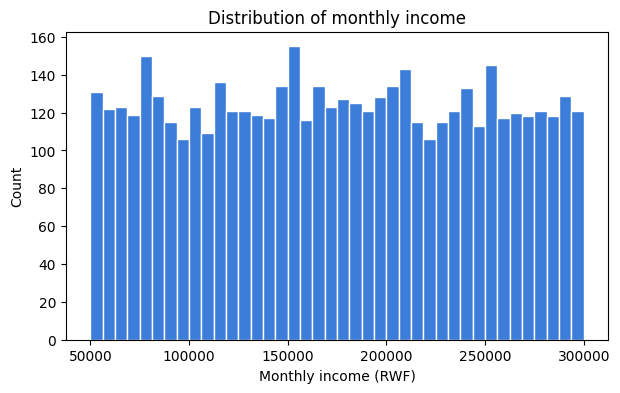

In [24]:
plt.figure(figsize=(7,4))
plt.hist(data["monthly_income"], bins=40, color="#3b7dd8", edgecolor="white")
plt.xlabel("Monthly income (RWF)")
plt.ylabel("Count")
plt.title("Distribution of monthly income")
plt.show()

Income spreads fairly evenly from about 50k to 300k RWF with no strong peak, so no heavy skew to correct.

**Viz 2 - correlation heatmap (used to decide what to drop)**

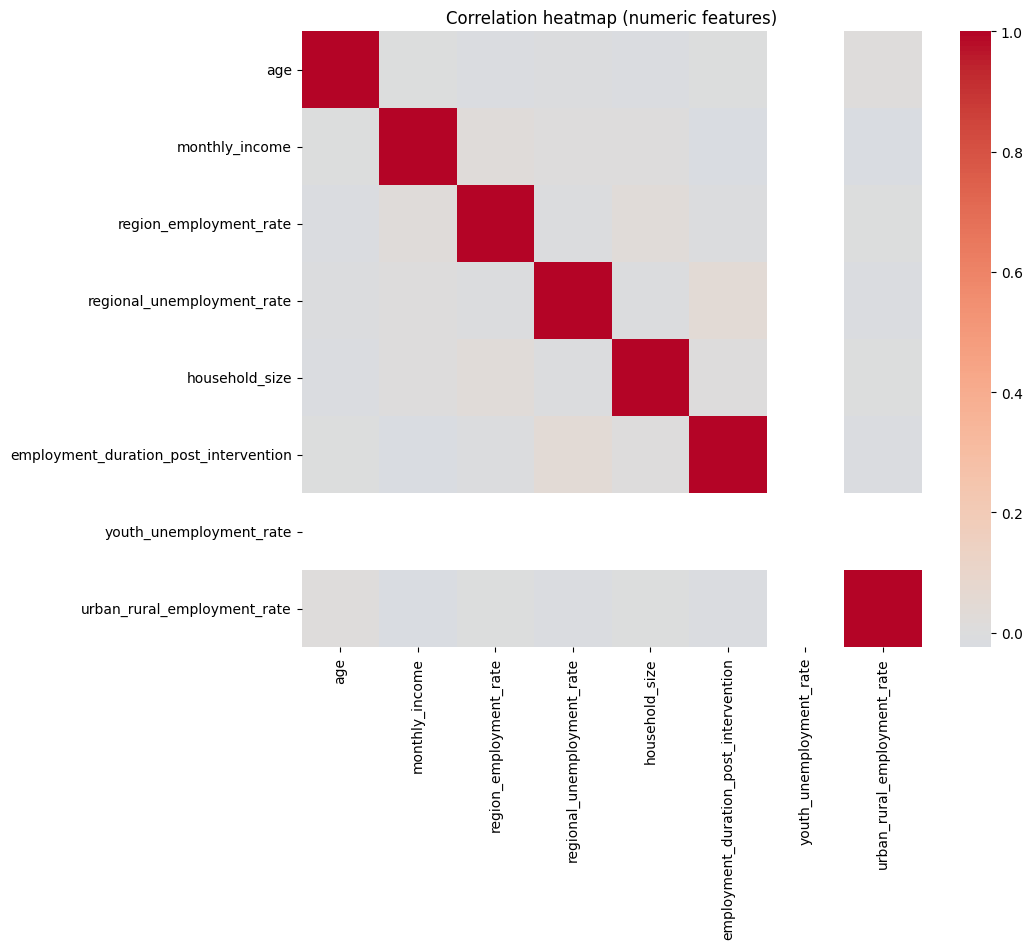

In [25]:
# numeric-only view to see what actually relates to income
num_view = data.select_dtypes(include=[np.number]).drop(columns=["record_id"])
plt.figure(figsize=(10,8))
sns.heatmap(num_view.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation heatmap (numeric features)")
plt.show()

In [26]:
# just the income column, sorted, to read it clearly
num_view.corr()["monthly_income"].sort_values(ascending=False)

,monthly_income
monthly_income,1.000000
region_employment_rate,0.020000
regional_unemployment_rate,0.007456
household_size,0.005481
age,0.002795
employment_duration_post_intervention,-0.024359
urban_rural_employment_rate,-0.024456
youth_unemployment_rate,NaN


The heatmap is the key interpretation step. Every numeric feature correlates with income at basically **0** (all below |0.03|), and `youth_unemployment_rate` is a single constant value. So no numeric feature is a strong driver, and constant / all-empty / id columns carry no signal and will be dropped. We still keep the categorical profile fields (education, sector, region...) because the model needs a full profile to score any worker.

**1.3 Feature engineering and encoding**
---

In [28]:
# drop what carries no signal: id, all-empty col, constant col, and the target-leaking flag
drop_cols = ["record_id", "youth_unemployment_rate", "employment_outcome"]
data = data.drop(columns=drop_cols)

# booleans -> 0/1
for c in ["education_mismatch", "training_participation"]:
    data[c] = data[c].astype(int)

# two-category text -> 0/1
data["gender"] = (data["gender"] == "Male").astype(int)
data["location_type"] = (data["location_type"] == "Urban").astype(int)
data["formal_informal"] = (data["formal_informal"] == "Formal").astype(int)

# ordered categories -> ranked numbers
data["education_level"] = data["education_level"].map(
    {"Primary or Less": 1, "Secondary": 2, "TVET": 2.5, "University": 3})
data["digital_skills_level"] = data["digital_skills_level"].map(
    {"Basic": 1, "Intermediate": 2, "Advanced": 3})
data["household_income"] = data["household_income"].map(
    {"Low": 1, "Medium": 2, "High": 3})
data["intervention_effectiveness"] = data["intervention_effectiveness"].map(
    {"Ineffective": 1, "Moderately Effective": 2, "Effective": 3})

In [30]:
data

,age,gender,education_level,education_mismatch,sector_of_interest,current_employment_sector,formal_informal,region,location_type,monthly_income,region_employment_rate,regional_unemployment_rate,digital_skills_level,technical_skills,training_participation,program_type,household_income,household_size,intervention_effectiveness,employment_duration_post_intervention,urban_rural_employment_rate
0,21,0,2.5,0,Agriculture,Agriculture,0,Kigali,1,116417.11,62.63,25.35,3,[o],1,Business Development,2,2,2,9.0,76.42
1,17,0,2.5,0,Retail,Retail,0,Kigali,0,102002.15,84.97,18.48,2,[],1,Digital Skills,2,2,3,11.0,31.11
2,17,1,2.5,0,Construction,Construction,0,Kigali,1,194184.21,61.70,29.55,1,[],0,None,2,7,1,10.0,70.70
3,25,0,1.0,0,Education,Education,1,Kigali,1,151178.79,79.71,16.60,3,"['Marketing', 'Project Management']",0,None,2,2,2,11.0,70.04
4,21,1,2.0,0,Retail,Retail,0,Kigali,1,243337.48,71.86,27.23,3,"['Marketing', 'Project Management']",0,None,2,7,1,2.0,57.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,21,1,2.5,0,Construction,Construction,1,Kigali,1,81682.96,64.22,12.20,3,[],1,Business Development,2,1,1,5.0,61.74
9991,20,1,2.0,0,Construction,Construction,1,Southern,0,65787.73,44.35,17.97,1,['Data Analysis'],1,None,1,1,2,7.0,33.96
9995,21,1,3.0,0,Education,Education,0,Kigali,1,75799.11,81.64,18.19,3,"['Marketing', 'Project Management']",0,None,1,8,3,4.0,79.82
9998,23,1,2.5,0,Agriculture,Agriculture,0,Kigali,1,125162.35,43.61,13.92,2,['Coding'],0,None,2,3,3,11.0,58.85


In [31]:
# technical_skills is stored as a messy list-string, turn it into a skill count
def count_skills(v):
    try:
        items = ast.literal_eval(v)
        return len([x for x in items if isinstance(x, str) and len(x) > 1])
    except Exception:
        return 0

data["skill_count"] = data["technical_skills"].apply(count_skills)
data = data.drop(columns=["technical_skills"])

In [32]:
data.head()

,age,gender,education_level,education_mismatch,sector_of_interest,current_employment_sector,formal_informal,region,location_type,monthly_income,region_employment_rate,regional_unemployment_rate,digital_skills_level,training_participation,program_type,household_income,household_size,intervention_effectiveness,employment_duration_post_intervention,urban_rural_employment_rate,skill_count
0,21,0,2.5,0,Agriculture,Agriculture,0,Kigali,1,116417.11,62.63,25.35,3,1,Business Development,2,2,2,9.0,76.42,0
1,17,0,2.5,0,Retail,Retail,0,Kigali,0,102002.15,84.97,18.48,2,1,Digital Skills,2,2,3,11.0,31.11,0
2,17,1,2.5,0,Construction,Construction,0,Kigali,1,194184.21,61.70,29.55,1,0,None,2,7,1,10.0,70.70,0
3,25,0,1.0,0,Education,Education,1,Kigali,1,151178.79,79.71,16.60,3,0,None,2,2,2,11.0,70.04,2
4,21,1,2.0,0,Retail,Retail,0,Kigali,1,243337.48,71.86,27.23,3,0,None,2,7,1,2.0,57.05,2


In [33]:
# many-category text -> one-hot columns
data = pd.get_dummies(
    data,
    columns=["sector_of_interest", "current_employment_sector", "region", "program_type"],
    drop_first=True)

# make sure everything is numeric now
data = data.astype(float)
data.shape

(4973, 34)

In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4973 entries, 0 to 9999
Data columns (total 34 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   age                                     4973 non-null   float64
 1   gender                                  4973 non-null   float64
 2   education_level                         4973 non-null   float64
 3   education_mismatch                      4973 non-null   float64
 4   formal_informal                         4973 non-null   float64
 5   location_type                           4973 non-null   float64
 6   monthly_income                          4973 non-null   float64
 7   region_employment_rate                  4973 non-null   float64
 8   regional_unemployment_rate              4973 non-null   float64
 9   digital_skills_level                    4973 non-null   float64
 10  training_participation                  4973 non-null   float64
 

**Interaction features** - combine columns so the model can catch non-linear profile effects.

In [35]:
data["edu_x_age"] = data["education_level"] * data["age"]
data["age_sq"] = data["age"] ** 2
data["urban_formal"] = data["location_type"] * data["formal_informal"]
data.head(3)

,age,gender,education_level,education_mismatch,formal_informal,location_type,monthly_income,region_employment_rate,regional_unemployment_rate,digital_skills_level,training_participation,household_income,household_size,intervention_effectiveness,employment_duration_post_intervention,urban_rural_employment_rate,skill_count,sector_of_interest_Construction,sector_of_interest_Education,sector_of_interest_Healthcare,sector_of_interest_ICT,sector_of_interest_Retail,current_employment_sector_Construction,current_employment_sector_Education,current_employment_sector_Healthcare,current_employment_sector_ICT,current_employment_sector_Retail,region_Kigali,region_Northern,region_Southern,region_Western,program_type_Digital Skills,program_type_None,program_type_Vocational Training,edu_x_age,age_sq,urban_formal
0,21.0,0.0,2.5,0.0,0.0,1.0,116417.11,62.63,25.35,3.0,1.0,2.0,2.0,2.0,9.0,76.42,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,52.5,441.0,0.0
1,17.0,0.0,2.5,0.0,0.0,0.0,102002.15,84.97,18.48,2.0,1.0,2.0,2.0,3.0,11.0,31.11,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,42.5,289.0,0.0
2,17.0,1.0,2.5,0.0,0.0,1.0,194184.21,61.70,29.55,1.0,0.0,2.0,7.0,1.0,10.0,70.70,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,42.5,289.0,0.0


**1.4 Train / test split and standardization**
---

In [36]:
X = data.drop(columns=["monthly_income"])
y = data["monthly_income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42)
print("train:", X_train.shape, " test:", X_test.shape)

train: (3978, 36)  test: (995, 36)


# 1.5 Standardization

In [37]:
# scale features (needed for SGD / linear family; harmless to keep a scaled copy)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# quick check: scaled train mean ~0, std ~1
print("mean:", round(X_train_scaled.mean(), 4), " std:", round(X_train_scaled.std(), 4))

mean: 0.0  std: 0.986


**2. Models: linear regression, decision tree, random forest and SGD (gradient descent)**
---
Comparing stochastic gradient descent against three other regressors, and tune more than one hyperparameter on each (fixing the earlier feedback about single-hyperparameter tuning).

In [38]:
# helper to score a fitted model on train and test
def evaluate(name, model, Xtr, Xte):
    ptr, pte = model.predict(Xtr), model.predict(Xte)
    return {
        "Model": name,
        "Train_RMSE": np.sqrt(mean_squared_error(y_train, ptr)),
        "Test_RMSE":  np.sqrt(mean_squared_error(y_test, pte)),
        "Test_MAE":   mean_absolute_error(y_test, pte),
        "Test_R2":    r2_score(y_test, pte),
    }, pte

**2.1 Linear Regression (ordinary least squares)**

In [39]:
lin = LinearRegression()
lin.fit(X_train_scaled, y_train)
lin_score, y_pred_lin = evaluate("Linear Regression", lin, X_train_scaled, X_test_scaled)
lin_score

{'Model': 'Linear Regression',
 'Train_RMSE': np.float64(71801.36914975557),
 'Test_RMSE': np.float64(71186.16499501857),
 'Test_MAE': 61313.77521595759,
 'Test_R2': -0.003401110396714424}

**2.2 Decision Tree** - tuned on max_depth, min_samples_leaf and min_samples_split.

In [40]:
tree_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    {"max_depth": [3, 5, 8, None],
     "min_samples_leaf": [1, 10, 50],
     "min_samples_split": [2, 20]},
    cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
tree_grid.fit(X_train, y_train)
tree = tree_grid.best_estimator_
print("best tree params:", tree_grid.best_params_)
tree_score, y_pred_tree = evaluate("Decision Tree", tree, X_train, X_test)
tree_score

best tree params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


{'Model': 'Decision Tree',
 'Train_RMSE': np.float64(71852.6484187929),
 'Test_RMSE': np.float64(71811.53680795111),
 'Test_MAE': 61815.70980393956,
 'Test_R2': -0.021108345106451765}

**2.3 Random Forest** - tuned on n_estimators, max_depth and min_samples_leaf.

In [41]:
forest_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {"n_estimators": [100, 200],
     "max_depth": [5, 10, None],
     "min_samples_leaf": [1, 20]},
    cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
forest_grid.fit(X_train, y_train)
forest = forest_grid.best_estimator_
print("best forest params:", forest_grid.best_params_)
forest_score, y_pred_forest = evaluate("Random Forest", forest, X_train, X_test)
forest_score

best forest params: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 200}


{'Model': 'Random Forest',
 'Train_RMSE': np.float64(69775.82362407526),
 'Test_RMSE': np.float64(71260.5320415421),
 'Test_MAE': 61347.25210598684,
 'Test_R2': -0.005498679614310609}

**2.4 SGD Regressor (linear regression via gradient descent)** - tuned on alpha, penalty, eta0 and max_iter.

In [42]:
sgd_grid = GridSearchCV(
    SGDRegressor(random_state=42, learning_rate="invscaling"),
    {"alpha": [1e-4, 1e-3, 1e-2],
     "penalty": ["l2", "l1"],
     "eta0": [0.001, 0.01],
     "max_iter": [1000, 2000]},
    cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
sgd_grid.fit(X_train_scaled, y_train)
sgd = sgd_grid.best_estimator_
print("best sgd params:", sgd_grid.best_params_)
sgd_score, y_pred_sgd = evaluate("SGD Regressor", sgd, X_train_scaled, X_test_scaled)
sgd_score

best sgd params: {'alpha': 0.01, 'eta0': 0.001, 'max_iter': 1000, 'penalty': 'l2'}


{'Model': 'SGD Regressor',
 'Train_RMSE': np.float64(71828.04729329103),
 'Test_RMSE': np.float64(71118.4144157833),
 'Test_MAE': 61221.64229890277,
 'Test_R2': -0.0014920693243254401}

**2.5 Two extra linear variants (Ridge & Lasso), each with alpha tuned**

In [43]:
ridge = GridSearchCV(Ridge(), {"alpha": [0.1, 1, 10, 100]}, cv=3,
                     scoring="neg_root_mean_squared_error").fit(X_train_scaled, y_train).best_estimator_
lasso = GridSearchCV(Lasso(max_iter=5000), {"alpha": [0.1, 1, 10, 100]}, cv=3,
                     scoring="neg_root_mean_squared_error").fit(X_train_scaled, y_train).best_estimator_
ridge_score, _ = evaluate("Ridge", ridge, X_train_scaled, X_test_scaled)
lasso_score, _ = evaluate("Lasso", lasso, X_train_scaled, X_test_scaled)
ridge_score, lasso_score

({'Model': 'Ridge',
  'Train_RMSE': np.float64(71824.79795792457),
  'Test_RMSE': np.float64(71112.85799865508),
  'Test_MAE': 61223.69164600974,
  'Test_R2': -0.0013355841059548013},
 {'Model': 'Lasso',
  'Train_RMSE': np.float64(71833.44870409988),
  'Test_RMSE': np.float64(71109.06362101325),
  'Test_MAE': 61223.06425749074,
  'Test_R2': -0.0012287301812081708})

**2.6 Prediction on one row of the test set**
---
Same single test row passed through every model.

In [44]:
row_scaled = X_test_scaled[0].reshape(1, -1)
row_raw = X_test.iloc[[0]]

print("actual income     :", round(y_test.iloc[0], 2))
print("linear regression :", round(lin.predict(row_scaled)[0], 2))
print("decision tree     :", round(tree.predict(row_raw)[0], 2))
print("random forest     :", round(forest.predict(row_raw)[0], 2))
print("sgd               :", round(sgd.predict(row_scaled)[0], 2))

actual income     : 286112.55
linear regression : 176268.95
decision tree     : 171985.68
random forest     : 175608.56
sgd               : 173654.18


**2.7 Loss curve for train and test (gradient descent)**
---

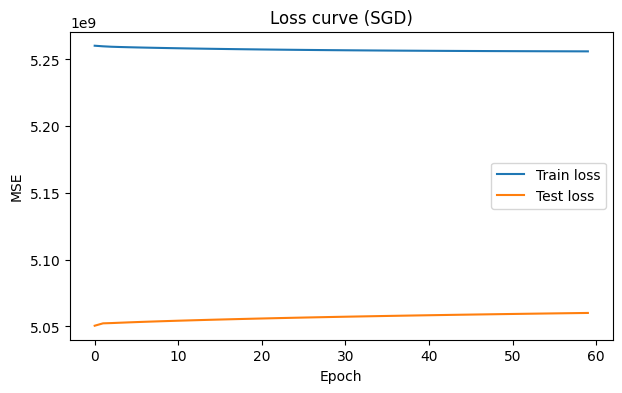

In [45]:
# train SGD one epoch at a time and record MSE on train and test
loss_model = SGDRegressor(learning_rate="invscaling", eta0=0.01, alpha=1e-4,
                          penalty="l2", random_state=42, warm_start=True, max_iter=1, tol=None)
train_loss, test_loss = [], []
for epoch in range(60):
    loss_model.fit(X_train_scaled, y_train)
    train_loss.append(mean_squared_error(y_train, loss_model.predict(X_train_scaled)))
    test_loss.append(mean_squared_error(y_test, loss_model.predict(X_test_scaled)))

plt.figure(figsize=(7,4))
plt.plot(train_loss, label="Train loss")
plt.plot(test_loss, label="Test loss")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("Loss curve (SGD)")
plt.legend(); plt.show()

The loss is basically flat from the start and the axis is scaled by 1e9, so the small drift is tiny relative to the ~5.2 billion MSE. Test loss even sits slightly below train loss, so there is no overfitting — the model just has almost nothing to learn because the features barely relate to income.

**B.8 Scatter of actual vs predicted (where the line passes through the data)**
---

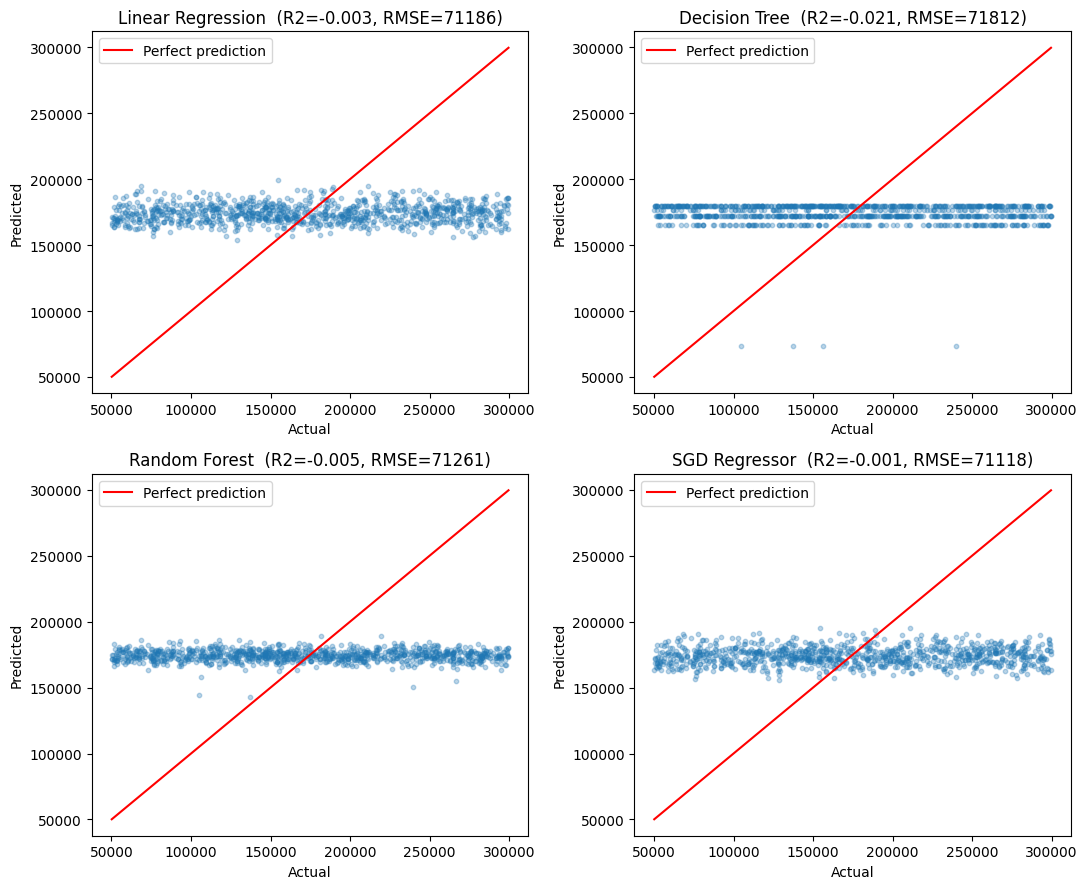

In [46]:
fig, ax = plt.subplots(2, 2, figsize=(11, 9))
pairs = [("Linear Regression", y_pred_lin, lin_score),
         ("Decision Tree", y_pred_tree, tree_score),
         ("Random Forest", y_pred_forest, forest_score),
         ("SGD Regressor", y_pred_sgd, sgd_score)]
for a, (name, pred, sc) in zip(ax.ravel(), pairs):
    a.scatter(y_test, pred, alpha=0.3, s=10)
    a.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
           color="red", label="Perfect prediction")
    a.set_title(f"{name}  (R2={sc['Test_R2']:.3f}, RMSE={sc['Test_RMSE']:.0f})")
    a.set_xlabel("Actual"); a.set_ylabel("Predicted"); a.legend()
plt.tight_layout(); plt.show()

Predictions cluster around the mean income instead of following the red line. That is the visual signature of weak features: the models fall back on the average because nothing in the profile strongly moves income here.

**C. Compare models and save the best**
---

In [47]:
results = pd.DataFrame([lin_score, tree_score, forest_score, sgd_score, ridge_score, lasso_score])
results = results.sort_values("Test_RMSE").reset_index(drop=True)
results

,Model,Train_RMSE,Test_RMSE,Test_MAE,Test_R2
0,Lasso,71833.448704,71109.063621,61223.064257,-0.001229
1,Ridge,71824.797958,71112.857999,61223.691646,-0.001336
2,SGD Regressor,71828.047293,71118.414416,61221.642299,-0.001492
3,Linear Regression,71801.369150,71186.164995,61313.775216,-0.003401
4,Random Forest,69775.823624,71260.532042,61347.252106,-0.005499
5,Decision Tree,71852.648419,71811.536808,61815.709804,-0.021108


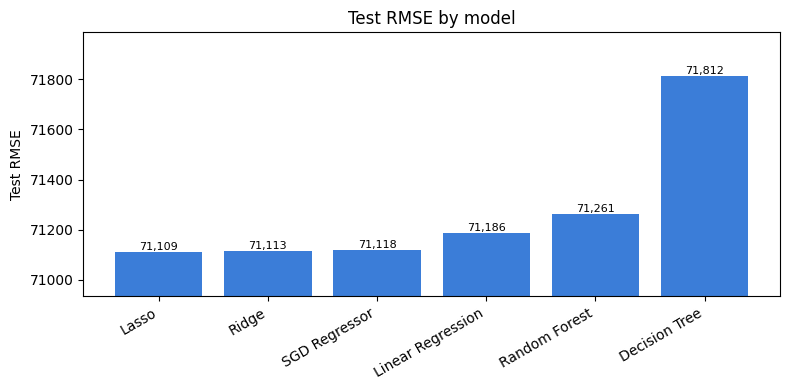

In [53]:
plt.figure(figsize=(8,4))
bars = plt.bar(results["Model"], results["Test_RMSE"], color="#3b7dd8")
plt.ylabel("Test RMSE"); plt.title("Test RMSE by model")

# zoom the axis to where the bars actually differ
lo, hi = results["Test_RMSE"].min(), results["Test_RMSE"].max()
pad = (hi - lo) * 0.25
plt.ylim(lo - pad, hi + pad)

# show the real number on each bar
for b, v in zip(bars, results["Test_RMSE"]):
    plt.text(b.get_x() + b.get_width()/2, v, f"{v:,.0f}",
             ha="center", va="bottom", fontsize=8)

plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

Best model = lowest test RMSE. The tree-based models score a little worse on the test set, so a linear model (Lasso) comes out on top and generalises best here.

In [49]:
best_name = results.iloc[0]["Model"]
best_lookup = {"Linear Regression": lin, "Decision Tree": tree, "Random Forest": forest,
               "SGD Regressor": sgd, "Ridge": ridge, "Lasso": lasso}
best_model = best_lookup[best_name]
print("best model:", best_name)

best model: Lasso


**Feature importance / coefficients of the best model**

In [50]:
if hasattr(best_model, "coef_"):
    imp = pd.Series(best_model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
else:
    imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
imp.head(10)

,0
region_Kigali,-2715.133165
skill_count,-2623.895483
region_Southern,-2513.359508
digital_skills_level,1976.910244
region_employment_rate,1738.664794
program_type_None,1259.398646
employment_duration_post_intervention,-1248.559295
urban_rural_employment_rate,-1214.755277
sector_of_interest_ICT,1209.816150
sector_of_interest_Retail,-1149.692679


Even the top-weighted features have small effects, which matches the flat correlations. Region and sector move income slightly more than the rest, so in this data *where* a youth works matters a little more than their education level.

In [51]:
# save ONE file that carries everything the prediction tool needs
bundle = {
    "model": best_model,
    "scaler": scaler,
    "columns": list(X.columns),
    "uses_scaler": hasattr(best_model, "coef_"),
}
joblib.dump(bundle, "best_model.pkl")
print("saved best_model.pkl")

saved best_model.pkl


**D. Prediction script for the Ku ndege tool**
---
Loads the saved model and turns a simple profile into an income estimate.

In [52]:
bundle = joblib.load("best_model.pkl")
best_model = bundle["model"]
scaler = bundle["scaler"]
feature_columns = bundle["columns"]
USES_SCALER = bundle["uses_scaler"]   # linear models were trained on scaled data

def estimate_income(age, education_level, gender, location_type, formal, region,
                    sector, digital_skills="Basic", skill_count=0):
    # start every feature at 0 then fill the ones we know
    row = {c: 0 for c in feature_columns}
    row["age"] = age
    row["age_sq"] = age ** 2
    row["gender"] = 1 if gender == "Male" else 0
    row["location_type"] = 1 if location_type == "Urban" else 0
    row["formal_informal"] = 1 if formal == "Formal" else 0
    edu_map = {"Primary or Less": 1, "Secondary": 2, "TVET": 2.5, "University": 3}
    row["education_level"] = edu_map.get(education_level, 1)
    row["digital_skills_level"] = {"Basic": 1, "Intermediate": 2, "Advanced": 3}.get(digital_skills, 1)
    row["skill_count"] = skill_count
    row["edu_x_age"] = row["education_level"] * age
    row["urban_formal"] = row["location_type"] * row["formal_informal"]
    # one-hot columns follow the pattern "region_Western", "current_employment_sector_ICT" ...
    for col, val in [(f"region_{region}", 1),
                     (f"sector_of_interest_{sector}", 1),
                     (f"current_employment_sector_{sector}", 1)]:
        if col in row:
            row[col] = val

    x = pd.DataFrame([row])[feature_columns]
    if USES_SCALER:
        x = scaler.transform(x)
    pred = best_model.predict(x)[0]
    print(f"Based on your profile, you should earn approximately RWF {pred:,.0f} per month.")
    return pred

# example: a 22 year old with secondary education doing informal construction work in Kigali
estimate_income(age=22, education_level="Secondary", gender="Male",
                location_type="Urban", formal="Informal", region="Kigali",
                sector="Construction", digital_skills="Basic", skill_count=1)

Based on your profile, you should earn approximately RWF 168,194 per month.


np.float64(168194.23676998608)

**Summary**

We predicted youth monthly income from a full profile. Missing income (unemployed youth) was dropped with justification, feature gaps were imputed, everything was encoded and scaled, and SGD was compared against Linear Regression, Decision Tree, Random Forest, Ridge and Lasso with several tuned hyperparameters each. A linear model generalised best and was saved for the Ku ndege prediction tool. The honest finding is that this dataset carries very little signal linking profile to income, so the estimates stay close to the average - useful as a rough benchmark rather than a precise wage.